# Projeto 1 - Parte I: Redes Neurais para reconhecimento de dígitos

**Disciplina:** MS571  
**Integrantes:** _preencher_  
**Data:** _preencher_

## Objetivo e escopo

Este notebook desenvolve, do início ao fim, uma rede neural regularizada para classificar as 5.000 imagens de dígitos manuscritos fornecidas. Cada imagem $20\times20$ é representada por um vetor com 400 atributos. A solução segue o algoritmo das notas de aula: propagação direta, função de custo multiclasse, retropropagação, regularização sem penalizar os biases, inicialização aleatória, descida do gradiente e checagem bilateral do gradiente. O gradiente conjugado é chamado por `scipy.optimize.minimize`, como autorizado pelo enunciado; a rede, o custo e o backpropagation continuam sendo implementados explicitamente.

O código não depende de classificadores prontos e aceita:

- qualquer quantidade de exemplos;
- rótulos numéricos não necessariamente começando em zero;
- qualquer número de classes;
- qualquer quantidade de camadas escondidas e neurônios, por meio de `layer_sizes`.

> **Como executar:** coloque este notebook na mesma pasta de `ex3data1.mat` **ou** dos arquivos `imageMNIST.csv` e `labelMNIST.csv`. Execute as células na ordem. Para um teste rápido, defina a variável de ambiente `NN_FAST_MODE=1` antes de abrir o Jupyter. A execução completa usa os 5.000 exemplos e inclui experimentos com até 400 iterações do gradiente conjugado.


## 1. Bibliotecas, reprodutibilidade e configuração

São usadas apenas bibliotecas de suporte numérico, gráficos, leitura dos dados e otimização. Nenhuma biblioteca de redes neurais ou classificador pronto é utilizada. A semente fixa torna a inicialização e os experimentos reproduzíveis.


In [13]:
from pathlib import Path
from time import perf_counter
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.optimize import minimize
try:
    from IPython.display import display, Markdown
except ImportError:  # permite validação como script fora do Jupyter
    def display(obj):
        print(obj)
    def Markdown(text):
        return text

SEED = 2026
FAST_MODE = False
np.set_printoptions(precision=6, suppress=True)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.figsize": (8, 4.8), "axes.titlesize": 12})

print("Modo rápido:", FAST_MODE)
print("NumPy:", np.__version__)


Modo rápido: False
NumPy: 2.5.3


## 2. Leitura e inspeção dos dados

O carregador abaixo aceita tanto o arquivo MATLAB quanto os CSVs. Nos CSVs fornecidos, alguns números usam vírgula decimal dentro de aspas; por isso, a conversão explícita substitui a vírgula por ponto antes de transformar o texto em `float`. Os rótulos originais são $1,\ldots,10$, sendo `10` a codificação do dígito visual zero. Essa codificação é preservada internamente para não alterar os arquivos, mas a função `rotulo_visual` mostra `10` como `0` nos gráficos.

Não fazemos padronização adicional: os pixels já estão aproximadamente na escala $[0,1]$, com pequenas oscilações numéricas ao redor desses limites. Isso mantém os dados compatíveis com o material-base. A normalização para $[0,1]$ solicitada no enunciado será aplicada separadamente a cada filtro apenas na visualização final.


In [14]:
def localizar_arquivo(nomes):
    'Procura nomes exatos ou versões prefixadas nas pastas usuais.'
    pastas = [Path.cwd(), Path.cwd() / "project_sources", Path.cwd() / "dados"]
    for pasta in pastas:
        if not pasta.exists():
            continue
        for nome in nomes:
            direto = pasta / nome
            if direto.exists():
                return direto
            encontrados = sorted(pasta.glob(f"*{nome}"))
            if encontrados:
                return encontrados[0]
    return None


def ler_csv_decimal_misto(caminho):
    bruto = pd.read_csv(caminho, header=None, dtype=str)
    convertido = bruto.apply(
        lambda coluna: pd.to_numeric(
            coluna.str.replace(",", ".", regex=False), errors="raise"
        )
    )
    return convertido.to_numpy(dtype=float)


def carregar_mnist_local():
    mat_path = localizar_arquivo(["ex3data1.mat"])
    image_path = localizar_arquivo(["imageMNIST.csv"])
    label_path = localizar_arquivo(["labelMNIST.csv"])

    if image_path is not None and label_path is not None:
        X = ler_csv_decimal_misto(image_path)
        y = pd.read_csv(label_path, header=None).to_numpy().ravel().astype(int)
        origem = f"{image_path.name} + {label_path.name}"
    elif mat_path is not None:
        dados = loadmat(mat_path)
        X = np.asarray(dados["X"], dtype=float)
        y = np.asarray(dados["y"]).ravel().astype(int)
        origem = mat_path.name
    else:
        raise FileNotFoundError(
            "Coloque ex3data1.mat ou o par imageMNIST.csv/labelMNIST.csv "
            "na mesma pasta do notebook (ou em ./dados)."
        )

    if X.ndim != 2 or X.shape[1] != 400:
        raise ValueError(f"Esperava X com 400 colunas; recebido {X.shape}.")
    if X.shape[0] != y.size:
        raise ValueError("O número de imagens difere do número de rótulos.")
    if not np.isfinite(X).all():
        raise ValueError("Há pixels ausentes ou infinitos.")
    return X, y, origem


X, y, origem = carregar_mnist_local()
classes = np.unique(y)

print("Origem:", origem)
print("X:", X.shape, "| y:", y.shape)
print("Classes:", classes)
print(f"Intervalo dos pixels: [{X.min():.6f}, {X.max():.6f}]")


Origem: imageMNIST.csv + labelMNIST.csv
X: (5000, 400) | y: (5000,)
Classes: [ 1  2  3  4  5  6  7  8  9 10]
Intervalo dos pixels: [-0.131963, 1.127688]


,rótulo interno,dígito exibido,número de imagens
0,1,1,500
1,2,2,500
2,3,3,500
3,4,4,500
4,5,5,500
5,6,6,500
6,7,7,500
7,8,8,500
8,9,9,500
9,10,0,500


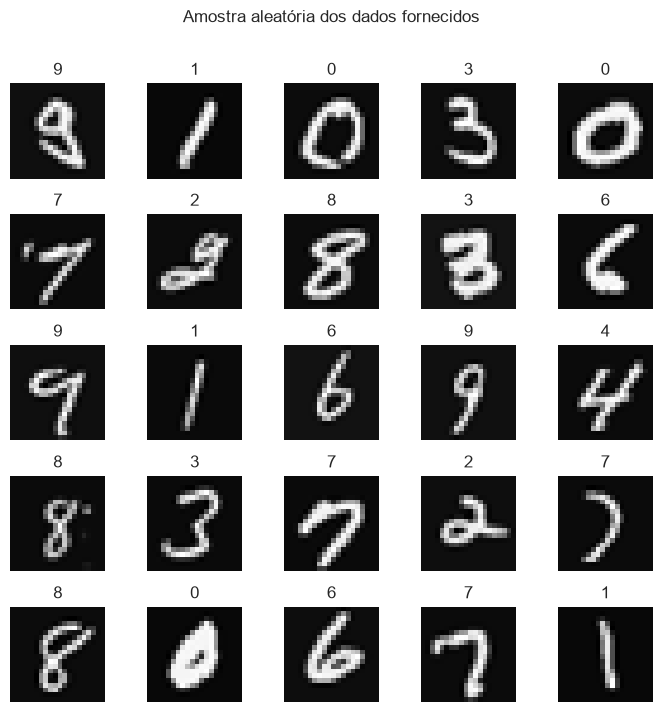

In [15]:
def rotulo_visual(rotulo):
    return 0 if int(rotulo) == 10 else int(rotulo)


contagens = pd.Series(y).value_counts().sort_index()
resumo_dados = pd.DataFrame({
    "rótulo interno": contagens.index,
    "dígito exibido": [rotulo_visual(v) for v in contagens.index],
    "número de imagens": contagens.values,
})
display(resumo_dados)

rng_vis = np.random.default_rng(SEED)
indices = rng_vis.choice(X.shape[0], size=25, replace=False)
fig, axes = plt.subplots(5, 5, figsize=(7, 7))
for ax, idx in zip(axes.ravel(), indices):
    ax.imshow(X[idx].reshape(20, 20, order="F"), cmap="gray")
    ax.set_title(str(rotulo_visual(y[idx])))
    ax.axis("off")
fig.suptitle("Amostra aleatória dos dados fornecidos", y=1.01)
plt.tight_layout()
plt.show()


## 3. Formulação matemática

Considere uma arquitetura $[s_1,s_2,\ldots,s_L]$. A matriz $\Theta^{(l)}$ tem dimensão $s_{l+1}\times(s_l+1)$; a coluna adicional contém os pesos do bias. Para cada camada,

$$z^{(l+1)}=\Theta^{(l)}a^{(l)},\qquad a^{(l+1)}=g(z^{(l+1)}),\qquad g(z)=\frac{1}{1+e^{-z}}.$$

Para $K$ classes, o alvo é codificado em *one-hot*. Seguindo as notas, cada saída sigmoide é tratada como uma regressão logística "classe contra as demais". A função de custo regularizada é

$$
J(\Theta)=-\frac{1}{m}\sum_{i=1}^{m}\sum_{k=1}^{K}
\left[y_k^{(i)}\log h_k^{(i)}+(1-y_k^{(i)})\log(1-h_k^{(i)})\right]
+\frac{\lambda}{2m}\sum_{l=1}^{L-1}\sum_j\sum_{r=1}^{s_l}(\Theta_{jr}^{(l)})^2.
$$

O índice $r$ começa em 1 no termo regularizador: a coluna de bias ($r=0$) não é penalizada. Na retropropagação,

$$\delta^{(L)}=a^{(L)}-y,\qquad
\delta^{(l)}=((\Theta^{(l)})^T\delta^{(l+1)})\odot g'(z^{(l)}).$$

A implementação é vetorizada sobre os exemplos, mas realiza exatamente a acumulação $\Delta^{(l)}=\sum_i\delta^{(l+1,i)}(a^{(l,i)})^T$ apresentada no material. Há laços apenas sobre as camadas, o que permite alterar `layer_sizes` sem reescrever o algoritmo.


In [16]:
def sigmoid(z):
    # O corte evita overflow sem alterar valores úteis da sigmoide.
    z = np.clip(z, -500.0, 500.0)
    return 1.0 / (1.0 + np.exp(-z))


def adicionar_bias(A):
    return np.column_stack([np.ones(A.shape[0]), A])


def one_hot(y, classes):
    y = np.asarray(y).ravel()
    classes = np.asarray(classes)
    posicoes = np.searchsorted(classes, y)
    if np.any(posicoes >= classes.size) or np.any(classes[posicoes] != y):
        raise ValueError("Há rótulo que não pertence ao conjunto de classes.")
    Y = np.zeros((y.size, classes.size))
    Y[np.arange(y.size), posicoes] = 1.0
    return Y


def inicializar_pesos(layer_sizes, seed=SEED):
    rng = np.random.default_rng(seed)
    pesos = []
    for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        epsilon = np.sqrt(6.0 / (fan_in + fan_out))
        W = rng.uniform(-epsilon, epsilon, size=(fan_out, fan_in + 1))
        pesos.append(W)
    return pesos


def empacotar(matrizes):
    return np.concatenate([M.ravel() for M in matrizes])


def desempacotar(parametros, layer_sizes):
    parametros = np.asarray(parametros)
    pesos, inicio = [], 0
    for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]):
        quantidade = fan_out * (fan_in + 1)
        fim = inicio + quantidade
        pesos.append(parametros[inicio:fim].reshape(fan_out, fan_in + 1))
        inicio = fim
    if inicio != parametros.size:
        raise ValueError("Tamanho do vetor de parâmetros incompatível com layer_sizes.")
    return pesos


def forward(X, pesos):
    ativacoes = [np.asarray(X, dtype=float)]
    pre_ativacoes = []
    for W in pesos:
        z = adicionar_bias(ativacoes[-1]) @ W.T
        pre_ativacoes.append(z)
        ativacoes.append(sigmoid(z))
    return ativacoes, pre_ativacoes


def custo_e_gradiente(parametros, X, y, layer_sizes, classes, lambda_reg=0.0):
    'Retorna J e dJ/dtheta para arquitetura arbitrária.'
    X = np.asarray(X, dtype=float)
    y = np.asarray(y).ravel()
    m = X.shape[0]
    pesos = desempacotar(parametros, layer_sizes)
    Y = one_hot(y, classes)
    ativacoes, pre_ativacoes = forward(X, pesos)

    # log(1 + exp(z)) - y*z é a entropia cruzada logística estável.
    z_saida = pre_ativacoes[-1]
    custo_dados = np.sum(np.logaddexp(0.0, z_saida) - Y * z_saida) / m
    penalidade = (lambda_reg / (2.0 * m)) * sum(
        np.sum(W[:, 1:] ** 2) for W in pesos
    )
    custo = custo_dados + penalidade

    gradientes = [None] * len(pesos)
    delta = ativacoes[-1] - Y
    for l in range(len(pesos) - 1, -1, -1):
        A_anterior_bias = adicionar_bias(ativacoes[l])
        grad = (delta.T @ A_anterior_bias) / m
        grad[:, 1:] += (lambda_reg / m) * pesos[l][:, 1:]
        gradientes[l] = grad

        if l > 0:
            delta = (delta @ pesos[l][:, 1:]) * (
                ativacoes[l] * (1.0 - ativacoes[l])
            )

    return float(custo), empacotar(gradientes)


def predizer(parametros, X, layer_sizes, classes):
    pesos = desempacotar(parametros, layer_sizes)
    saida = forward(X, pesos)[0][-1]
    return np.asarray(classes)[np.argmax(saida, axis=1)]


def acuracia(y_real, y_pred):
    return 100.0 * np.mean(np.asarray(y_real).ravel() == np.asarray(y_pred).ravel())


### 3.1 Por que a inicialização não pode ser zero?

Se todas as conexões de uma camada começassem iguais, seus neurônios receberiam os mesmos gradientes e continuariam idênticos após cada atualização. A inicialização aleatória quebra essa simetria. Foi adotado $\epsilon_{init}=\sqrt{6/(s_l+s_{l+1})}$, coerente com o notebook-base anexado e apropriado para evitar ativações iniciais excessivamente saturadas.


## 4. Checagem do gradiente

Antes do treinamento real, o backpropagation é comparado à aproximação por diferenças centrais

$$\frac{\partial J}{\partial\theta_j}\approx
\frac{J(\theta+\epsilon e_j)-J(\theta-\epsilon e_j)}{2\epsilon},\qquad \epsilon=10^{-4}.$$

Como essa rotina exige duas avaliações do custo por parâmetro, ela é executada apenas na pequena rede sugerida no enunciado: 3 entradas, 5 unidades escondidas, 3 saídas e 3 exemplos fictícios. A diferença relativa deve ficar próxima da precisão numérica; depois dessa validação, a checagem não participa do treinamento da MNIST.


In [17]:
def gradiente_numerico(funcao_custo, parametros, epsilon=1e-4):
    parametros = np.asarray(parametros, dtype=float)
    aproximado = np.zeros_like(parametros)
    for j in range(parametros.size):
        deslocamento = np.zeros_like(parametros)
        deslocamento[j] = epsilon
        J_mais = funcao_custo(parametros + deslocamento)
        J_menos = funcao_custo(parametros - deslocamento)
        aproximado[j] = (J_mais - J_menos) / (2.0 * epsilon)
    return aproximado


rng_check = np.random.default_rng(SEED)
X_check = rng_check.normal(size=(3, 3))
y_check = np.array([0, 1, 2])
classes_check = np.array([0, 1, 2])
camadas_check = [3, 5, 3]
theta_check = empacotar(inicializar_pesos(camadas_check, seed=7))

J_check, grad_bp = custo_e_gradiente(
    theta_check, X_check, y_check, camadas_check, classes_check, lambda_reg=0.7
)
grad_num = gradiente_numerico(
    lambda p: custo_e_gradiente(
        p, X_check, y_check, camadas_check, classes_check, lambda_reg=0.7
    )[0],
    theta_check,
    epsilon=1e-4,
)

diferenca_relativa = np.linalg.norm(grad_num - grad_bp) / (
    np.linalg.norm(grad_num) + np.linalg.norm(grad_bp)
)

comparacao_grad = pd.DataFrame({
    "gradiente numérico": grad_num,
    "backpropagation": grad_bp,
    "diferença absoluta": np.abs(grad_num - grad_bp),
})
display(comparacao_grad.head(15))
print(f"Custo da rede pequena: {J_check:.10f}")
print(f"Diferença relativa: {diferenca_relativa:.3e}")
assert diferenca_relativa < 1e-7, "A checagem do gradiente falhou."
print("Checagem aprovada: o backpropagation é consistente com o gradiente numérico.")


,gradiente numérico,backpropagation,diferença absoluta
0,0.104477,0.104477,1.035664e-10
1,0.061635,0.061635,4.890630e-12
2,0.132141,0.132141,3.385486e-12
3,-0.241868,-0.241868,2.831053e-10
4,-0.011513,-0.011513,5.734311e-12
5,0.150154,0.150154,8.747003e-12
6,-0.204296,-0.204296,3.922696e-13
7,0.132456,0.132456,5.694945e-12
8,0.047136,0.047136,2.163119e-11
9,-0.071819,-0.071819,3.059272e-11


Custo da rede pequena: 3.1788690171
Diferença relativa: 2.213e-10
Checagem aprovada: o backpropagation é consistente com o gradiente numérico.


## 5. Rede regularizada treinada por descida do gradiente

A arquitetura principal é $400\rightarrow25\rightarrow10$. Em cada iteração, todos os gradientes são calculados com os parâmetros antigos e só então os pesos são atualizados simultaneamente:

$$\Theta^{(l)}\leftarrow\Theta^{(l)}-\alpha D^{(l)}.$$

O histórico de $J(\Theta)$ é registrado para verificar convergência. A descida em lote é fiel ao algoritmo didático e deixa visível o papel de $\alpha$; sua principal desvantagem é exigir ajuste manual da taxa de aprendizado.


In [18]:
def treinar_gradiente_descendente(
    X, y, layer_sizes, classes, lambda_reg, alpha, n_iter, parametros_iniciais
):
    parametros = np.asarray(parametros_iniciais, dtype=float).copy()
    historico = []
    for iteracao in range(n_iter):
        custo, grad = custo_e_gradiente(
            parametros, X, y, layer_sizes, classes, lambda_reg
        )
        parametros -= alpha * grad
        historico.append(custo)
        if not np.isfinite(custo):
            raise FloatingPointError("O custo deixou de ser finito; reduza alpha.")
    custo_final = custo_e_gradiente(
        parametros, X, y, layer_sizes, classes, lambda_reg
    )[0]
    historico.append(custo_final)
    return parametros, np.asarray(historico)


layer_sizes = [X.shape[1], 25, classes.size]
lambda_gd = 1.0
alpha_gd = 0.8
n_iter_gd = 40 if FAST_MODE else 300

if FAST_MODE:
    rng_fast = np.random.default_rng(SEED)
    idx_treino = rng_fast.choice(X.shape[0], size=min(1000, X.shape[0]), replace=False)
    X_treino, y_treino = X[idx_treino], y[idx_treino]
else:
    X_treino, y_treino = X, y

theta_inicial = empacotar(inicializar_pesos(layer_sizes, seed=SEED))
inicio = perf_counter()
theta_gd, historico_gd = treinar_gradiente_descendente(
    X_treino, y_treino, layer_sizes, classes,
    lambda_reg=lambda_gd, alpha=alpha_gd, n_iter=n_iter_gd,
    parametros_iniciais=theta_inicial,
)
tempo_gd = perf_counter() - inicio

pred_gd = predizer(theta_gd, X_treino, layer_sizes, classes)
acc_gd = acuracia(y_treino, pred_gd)

print("Arquitetura:", layer_sizes)
print("Exemplos usados:", X_treino.shape[0])
print(f"Custo inicial: {historico_gd[0]:.6f}")
print(f"Custo final:   {historico_gd[-1]:.6f}")
print(f"Acurácia no conjunto usado no ajuste: {acc_gd:.2f}%")
print(f"Tempo: {tempo_gd:.2f} s")


Arquitetura: [400, 25, 10]
Exemplos usados: 5000
Custo inicial: 6.268003
Custo final:   0.715690
Acurácia no conjunto usado no ajuste: 91.92%
Tempo: 9.98 s


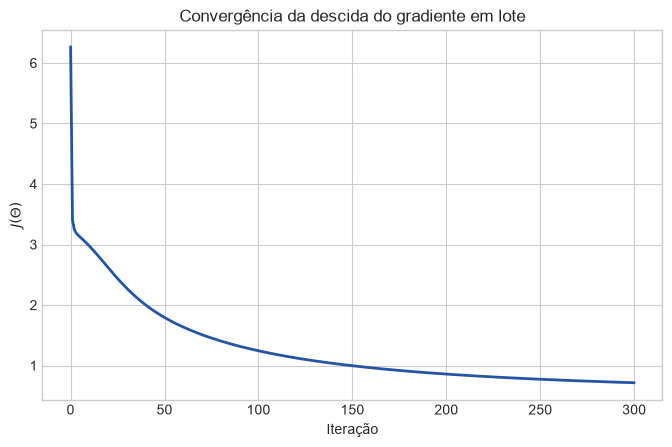

In [19]:
fig, ax = plt.subplots()
ax.plot(np.arange(historico_gd.size), historico_gd, color="#2455a4", lw=2)
ax.set(xlabel="Iteração", ylabel=r"$J(\Theta)$",
       title="Convergência da descida do gradiente em lote")
plt.show()

if historico_gd[-1] >= historico_gd[0]:
    warnings.warn("O custo não diminuiu; revise alpha_gd.")


### 5.1 Imagens classificadas incorretamente

A acurácia é a porcentagem de exemplos cujo maior valor na camada de saída corresponde ao rótulo correto. O painel abaixo mostra erros do classificador, com `V` para o valor verdadeiro e `P` para a previsão. Como a avaliação desta Parte I é feita nos próprios exemplos usados no ajuste, ela mede capacidade de ajuste, não generalização. A separação treino/validação/teste é objeto da Parte II.


Erros: 404 de 5000 (8.08%)


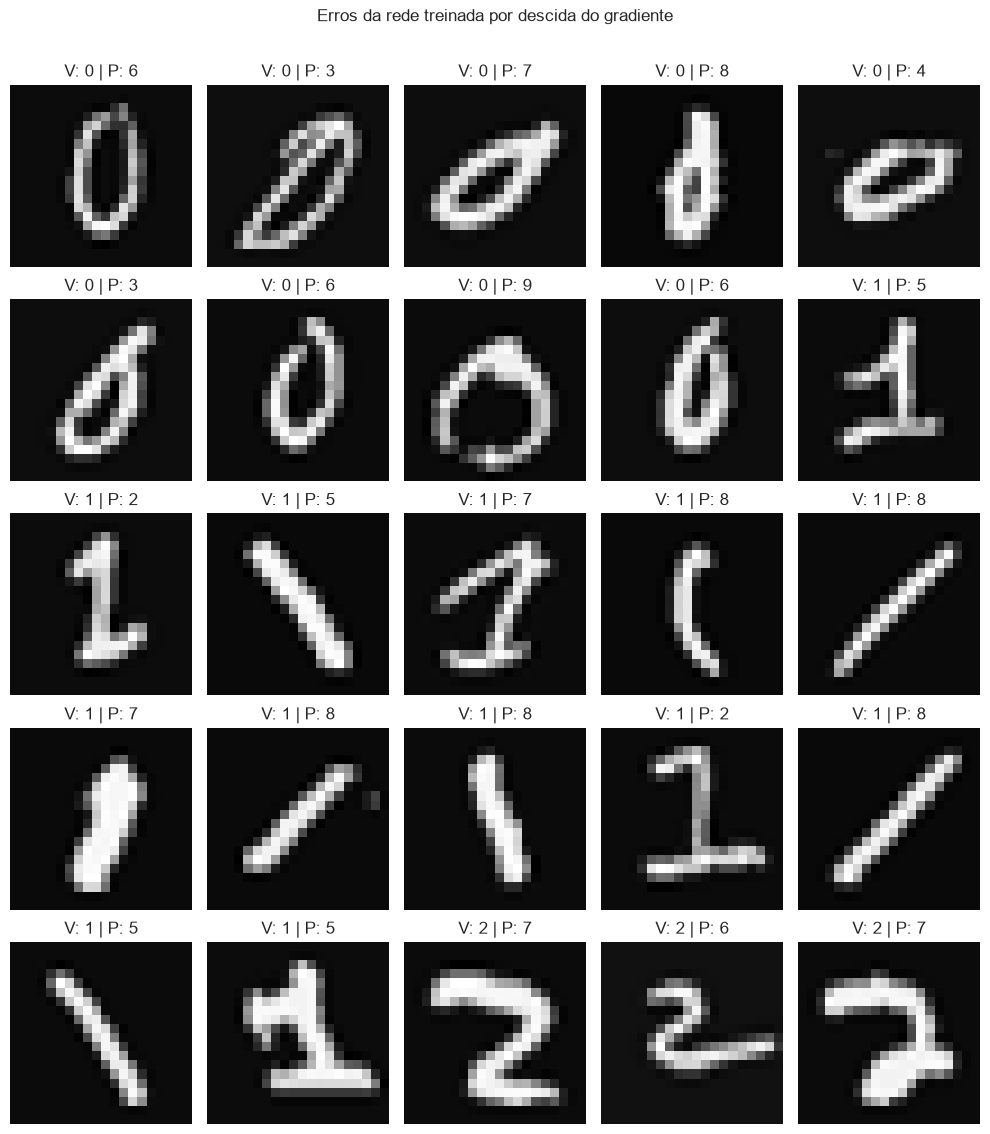

In [20]:
def mostrar_erros(X, y, pred, max_imagens=25, titulo="Erros de classificação"):
    errados = np.flatnonzero(np.asarray(y).ravel() != np.asarray(pred).ravel())
    print(f"Erros: {errados.size} de {len(y)} ({100*errados.size/len(y):.2f}%)")
    if errados.size == 0:
        print("Nenhum exemplo incorreto para mostrar.")
        return
    n = min(max_imagens, errados.size)
    colunas = 5
    linhas = int(np.ceil(n / colunas))
    fig, axes = plt.subplots(linhas, colunas, figsize=(10, 2.25 * linhas))
    axes = np.atleast_1d(axes).ravel()
    for ax, idx in zip(axes, errados[:n]):
        ax.imshow(X[idx].reshape(20, 20, order="F"), cmap="gray")
        ax.set_title(f"V: {rotulo_visual(y[idx])} | P: {rotulo_visual(pred[idx])}")
        ax.axis("off")
    for ax in axes[n:]:
        ax.axis("off")
    fig.suptitle(titulo, y=1.01)
    plt.tight_layout()
    plt.show()


mostrar_erros(X_treino, y_treino, pred_gd, max_imagens=25,
              titulo="Erros da rede treinada por descida do gradiente")


## 6. Gradiente conjugado: variação de iterações e regularização

O gradiente conjugado constrói direções de busca usando informação dos gradientes atuais e anteriores. Em contraste com a descida simples, ele também realiza busca linear interna e não requer escolher manualmente um $\alpha$ fixo. Sua lógica de otimização é fornecida pelo SciPy, conforme solicitado no projeto; cada avaliação de $J$ e $\nabla J$ é feita pelas rotinas autorais acima.

O experimento mantém a mesma inicialização em todos os casos, tornando a comparação mais justa. Primeiro variamos o limite de iterações com $\lambda=1$; depois variamos $\lambda$ com 200 iterações. A grade completa inclui 400 iterações. Em `FAST_MODE`, apenas três configurações curtas são usadas para verificação técnica.


In [21]:
def treinar_gradiente_conjugado(
    X, y, layer_sizes, classes, lambda_reg, maxiter, parametros_iniciais
):
    historico = []

    def objetivo(p):
        return custo_e_gradiente(p, X, y, layer_sizes, classes, lambda_reg)

    def callback(p):
        historico.append(objetivo(p)[0])

    resultado = minimize(
        objetivo,
        np.asarray(parametros_iniciais, dtype=float).copy(),
        method="CG",
        jac=True,
        callback=callback,
        options={"maxiter": int(maxiter), "gtol": 1e-5, "disp": False},
    )
    return resultado, np.asarray(historico)


if FAST_MODE:
    configuracoes = [(20, 0.0), (20, 1.0), (50, 1.0)]
else:
    configuracoes = [
        (50, 1.0), (100, 1.0), (200, 1.0), (400, 1.0),
        (200, 0.0), (200, 0.1), (200, 3.0),
    ]

resultados_cg = []
modelos_cg = {}
historicos_cg = {}

for maxiter, lambda_reg in configuracoes:
    inicio = perf_counter()
    resultado, historico = treinar_gradiente_conjugado(
        X_treino, y_treino, layer_sizes, classes,
        lambda_reg=lambda_reg, maxiter=maxiter,
        parametros_iniciais=theta_inicial,
    )
    tempo = perf_counter() - inicio
    pred = predizer(resultado.x, X_treino, layer_sizes, classes)
    chave = (maxiter, lambda_reg)
    modelos_cg[chave] = resultado.x
    historicos_cg[chave] = historico
    resultados_cg.append({
        "máx. iterações": maxiter,
        "lambda": lambda_reg,
        "iterações realizadas": resultado.nit,
        "avaliações da função": resultado.nfev,
        "custo final": resultado.fun,
        "acurácia (%)": acuracia(y_treino, pred),
        "tempo (s)": tempo,
        "convergência declarada": bool(resultado.success),
    })
    print(f"CG maxiter={maxiter:3d}, lambda={lambda_reg:g}: "
          f"J={resultado.fun:.5f}, acc={resultados_cg[-1]['acurácia (%)']:.2f}%")

tabela_cg = pd.DataFrame(resultados_cg).sort_values(["lambda", "máx. iterações"])
display(tabela_cg.round({
    "lambda": 3, "custo final": 6,
    "acurácia (%)": 2, "tempo (s)": 2,
}))


CG maxiter= 50, lambda=1: J=0.42577, acc=96.64%
CG maxiter=100, lambda=1: J=0.35103, acc=98.60%
CG maxiter=200, lambda=1: J=0.33203, acc=99.22%
CG maxiter=400, lambda=1: J=0.31414, acc=99.54%
CG maxiter=200, lambda=0: J=0.00126, acc=100.00%
CG maxiter=200, lambda=0.1: J=0.07622, acc=100.00%
CG maxiter=200, lambda=3: J=0.57148, acc=97.46%


,máx. iterações,lambda,iterações realizadas,avaliações da função,custo final,acurácia (%),tempo (s),convergência declarada
4,200,0.0,200,679,0.001260,100.00,16.28,False
5,200,0.1,200,552,0.076223,100.00,13.17,False
0,50,1.0,50,113,0.425770,96.64,4.89,False
1,100,1.0,100,231,0.351035,98.60,10.71,False
2,200,1.0,200,454,0.332033,99.22,17.83,False
3,400,1.0,400,897,0.314139,99.54,32.70,False
6,200,3.0,200,418,0.571482,97.46,11.16,False


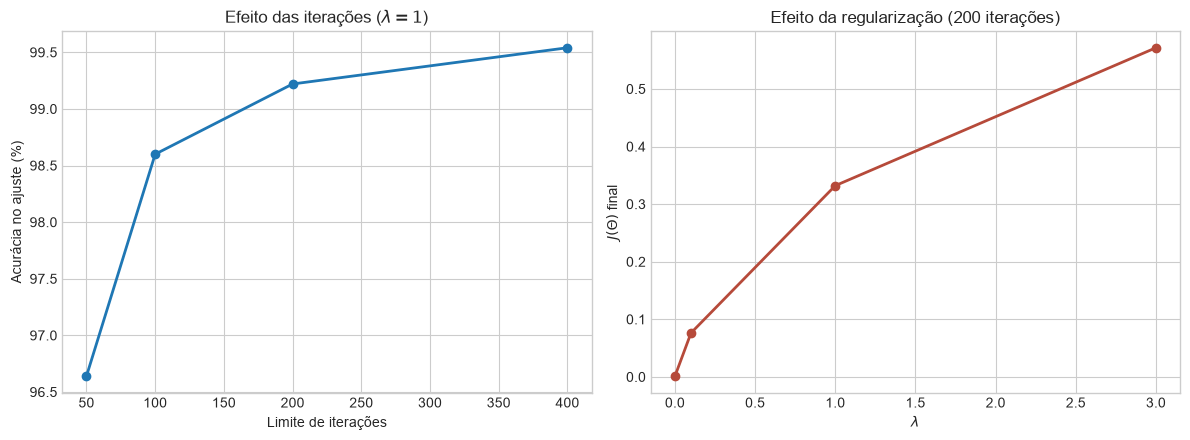

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

por_iteracao = tabela_cg[np.isclose(tabela_cg["lambda"], 1.0)].sort_values("máx. iterações")
axes[0].plot(por_iteracao["máx. iterações"], por_iteracao["acurácia (%)"], "o-", lw=2)
axes[0].set(xlabel="Limite de iterações", ylabel="Acurácia no ajuste (%)",
            title=r"Efeito das iterações ($\lambda=1$)")

alvo_iter = 20 if FAST_MODE else 200
por_lambda = tabela_cg[tabela_cg["máx. iterações"] == alvo_iter].sort_values("lambda")
axes[1].plot(por_lambda["lambda"], por_lambda["custo final"], "o-", lw=2, color="#b64a3a")
if (por_lambda["lambda"] > 0).all():
    axes[1].set_xscale("log")
axes[1].set(xlabel=r"$\lambda$", ylabel=r"$J(\Theta)$ final",
            title=f"Efeito da regularização ({alvo_iter} iterações)")

plt.tight_layout()
plt.show()


### 6.1 Interpretação dos experimentos

Mais iterações dão ao otimizador oportunidade de reduzir o custo, mas o ganho tende a diminuir e o tempo aumenta. A regularização acrescenta uma penalidade ao custo, portanto custos de diferentes $\lambda$ não devem ser interpretados isoladamente como se medissem exatamente a mesma quantidade. Valores muito altos de $\lambda$ comprimem os pesos e podem causar subajuste; $\lambda=0$ permite pesos maiores e pode favorecer sobreajuste. Nesta Parte I, escolher $\lambda$ pela acurácia de ajuste seria metodologicamente frágil. A escolha defensável será feita com validação na Parte II.

O campo “convergência declarada” também precisa de leitura cuidadosa: `False` normalmente significa apenas que o limite de iterações foi atingido, não que o modelo produzido seja inválido. A queda do custo, a norma do gradiente e a acurácia devem ser analisadas em conjunto.


## 7. Visualização das unidades escondidas

A linha $i$ de $\Theta^{(1)}$, sem o bias, possui 400 pesos. Ao reorganizá-la em $20\times20$, obtemos uma representação da região e do contraste aos quais a unidade escondida responde. Para cumprir o enunciado, cada imagem é escalada individualmente para $[0,1]$:

$$W_{esc}=\frac{W-\min(W)}{\max(W)-\min(W)}.$$

Essa normalização melhora a visualização, mas elimina a comparação direta da magnitude absoluta entre unidades; ela serve para estudar padrões espaciais, não a força relativa dos filtros.


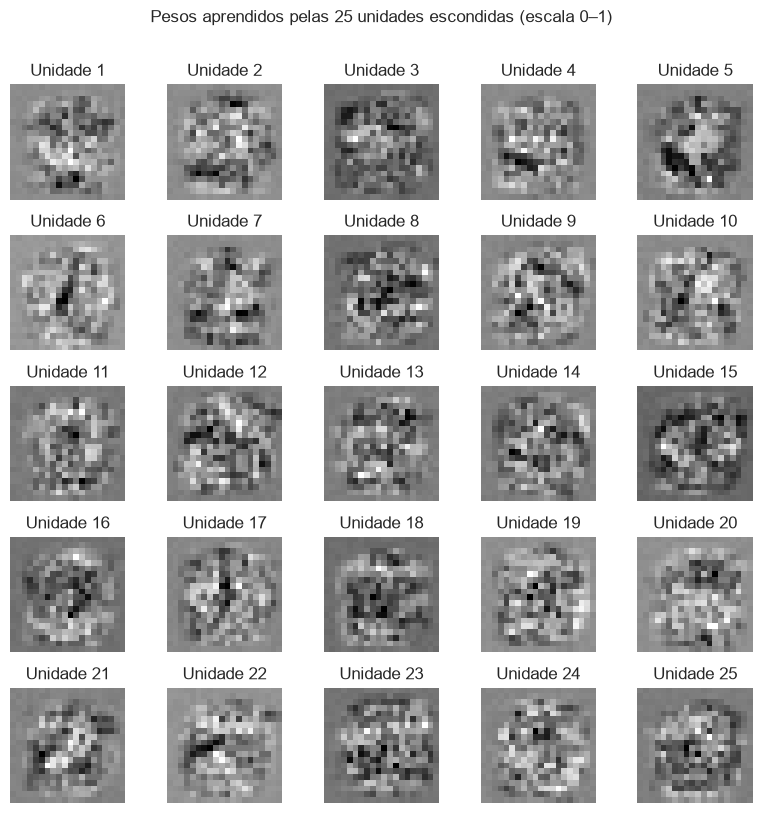

Erros: 0 de 5000 (0.00%)
Nenhum exemplo incorreto para mostrar.


In [23]:
# Seleciona a melhor configuração efetivamente regularizada (lambda > 0);
# lambda=0 permanece apenas como referência experimental.
candidatas_regularizadas = tabela_cg[tabela_cg["lambda"] > 0]
melhor_linha = candidatas_regularizadas.sort_values(
    ["acurácia (%)", "custo final"], ascending=[False, True]
).iloc[0]
melhor_chave = (int(melhor_linha["máx. iterações"]), float(melhor_linha["lambda"]))
theta_cg = modelos_cg[melhor_chave]
pred_cg = predizer(theta_cg, X_treino, layer_sizes, classes)

W1 = desempacotar(theta_cg, layer_sizes)[0][:, 1:]
fig, axes = plt.subplots(5, 5, figsize=(8, 8))
for i, ax in enumerate(axes.ravel()):
    filtro = W1[i].reshape(20, 20, order="F")
    minimo, maximo = filtro.min(), filtro.max()
    filtro_01 = (filtro - minimo) / (maximo - minimo) if maximo > minimo else np.zeros_like(filtro)
    ax.imshow(filtro_01, cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Unidade {i + 1}")
    ax.axis("off")
fig.suptitle("Pesos aprendidos pelas 25 unidades escondidas (escala 0–1)", y=1.01)
plt.tight_layout()
plt.show()

mostrar_erros(X_treino, y_treino, pred_cg, max_imagens=25,
              titulo=f"Erros do CG: maxiter={melhor_chave[0]}, lambda={melhor_chave[1]:g}")


## 8. Comparação final e discussão crítica

A tabela seguinte resume os dois métodos na mesma base de ajuste. O gradiente descendente tem implementação e diagnóstico intuitivos, mas depende de $\alpha$ e pode avançar lentamente. O gradiente conjugado evita uma taxa fixa e costuma atingir uma solução melhor em menos iterações externas, ao custo de buscas lineares e maior complexidade por iteração. Como a função de custo da rede não é convexa, nenhuma das duas rotinas garante o mínimo global; a inicialização aleatória influencia o resultado.


In [24]:
comparacao_final = pd.DataFrame([
    {
        "método": "Descida do gradiente",
        "lambda": lambda_gd,
        "iterações": n_iter_gd,
        "custo final": historico_gd[-1],
        "acurácia no ajuste (%)": acc_gd,
        "tempo (s)": tempo_gd,
    },
    {
        "método": "Gradiente conjugado",
        "lambda": melhor_chave[1],
        "iterações": int(melhor_linha["iterações realizadas"]),
        "custo final": float(melhor_linha["custo final"]),
        "acurácia no ajuste (%)": float(melhor_linha["acurácia (%)"]),
        "tempo (s)": float(melhor_linha["tempo (s)"]),
    },
])
display(comparacao_final.round({
    "lambda": 3, "custo final": 6,
    "acurácia no ajuste (%)": 2, "tempo (s)": 2,
}))

texto_resultados = fr'''
### Síntese produzida pela execução

- A checagem do gradiente apresentou diferença relativa **{diferenca_relativa:.3e}**, abaixo do limite adotado de $10^{{-7}}$; isso dá evidência numérica de que o backpropagation foi implementado corretamente.
- Com descida do gradiente, o custo passou de **{historico_gd[0]:.6f}** para **{historico_gd[-1]:.6f}**, e a acurácia no conjunto usado no ajuste foi **{acc_gd:.2f}%**.
- Entre as configurações **regularizadas** de gradiente conjugado executadas, a maior acurácia de ajuste foi **{melhor_linha['acurácia (%)']:.2f}%**, com limite de **{melhor_chave[0]}** iterações e $\lambda={melhor_chave[1]:g}$. O caso $\lambda=0$ foi mantido apenas como referência sem regularização.
- Esses números não estimam desempenho em dados novos, pois ainda não existe um conjunto de teste separado. Portanto, a conclusão legítima da Parte I é sobre funcionamento, otimização e capacidade de ajuste; generalização e seleção de $\lambda$ pertencem à Parte II.
'''
display(Markdown(texto_resultados))


,método,lambda,iterações,custo final,acurácia no ajuste (%),tempo (s)
0,Descida do gradiente,1.0,300,0.715690,91.92,9.98
1,Gradiente conjugado,0.1,200,0.076223,100.00,13.17



### Síntese produzida pela execução

- A checagem do gradiente apresentou diferença relativa **2.213e-10**, abaixo do limite adotado de $10^{-7}$; isso dá evidência numérica de que o backpropagation foi implementado corretamente.
- Com descida do gradiente, o custo passou de **6.268003** para **0.715690**, e a acurácia no conjunto usado no ajuste foi **91.92%**.
- Entre as configurações **regularizadas** de gradiente conjugado executadas, a maior acurácia de ajuste foi **100.00%**, com limite de **200** iterações e $\lambda=0.1$. O caso $\lambda=0$ foi mantido apenas como referência sem regularização.
- Esses números não estimam desempenho em dados novos, pois ainda não existe um conjunto de teste separado. Portanto, a conclusão legítima da Parte I é sobre funcionamento, otimização e capacidade de ajuste; generalização e seleção de $\lambda$ pertencem à Parte II.


### Limitações e decisões práticas

1. **Métrica no próprio conjunto de ajuste.** Ela atende à Parte I, mas é otimista. Não deve ser chamada de acurácia de teste.
2. **Saídas sigmoid independentes.** Esta é a formulação ensinada nas notas e usada no notebook-base. Uma softmax imporia probabilidades somando 1, mas mudaria o algoritmo solicitado.
3. **Custo computacional.** A checagem numérica é $O(p)$ avaliações de custo para $p$ parâmetros e, por isso, foi corretamente restrita à rede pequena.
4. **Regularização.** O bias foi excluído da penalização. A influência de $\lambda$ é mostrada, mas sua escolha final exige validação independente.
5. **Não convexidade.** Resultados podem mudar com a semente. Repetir o treinamento com várias inicializações seria uma extensão útil.
6. **Vetorização.** A soma sobre exemplos foi escrita com álgebra matricial. Isso não substitui o algoritmo por uma função pronta; apenas executa as mesmas equações de modo mais eficiente.

## Conclusão

A Parte I foi implementada de forma integrada: dados, rede genérica, custo regularizado, forward propagation, backpropagation, inicialização aleatória, gradiente descendente, checagem de gradiente, gradiente conjugado, análise de erros e interpretação visual das unidades escondidas. A checagem numérica é a principal evidência de correção das derivadas. As curvas e tabelas permitem comparar custo, acurácia e tempo, enquanto a análise ressalta que boa acurácia de ajuste não substitui a avaliação de generalização requerida na Parte II.


## Referências

- **Notas de aula da disciplina MS571.** Capítulos 3 (regressão logística e otimização avançada), 5 (redes neurais, backpropagation, checagem de gradiente e inicialização aleatória) e 6 (avaliação e regularização). Material fornecido, 2022.
- **Projeto 1 - Parte I: Redes Neurais.** Enunciado fornecido na disciplina MS571, 2026.
- **Notebook `neural_networks.ipynb`.** Código-base fornecido: leitura de `ex3data1.mat`, sigmoide, custo regularizado, backpropagation e descida do gradiente.
- GLOROT, X.; BENGIO, Y. *Understanding the difficulty of training deep feedforward neural networks*. Proceedings of AISTATS, 2010.
- LECUN, Y.; BOTTOU, L.; BENGIO, Y.; HAFFNER, P. *Gradient-based learning applied to document recognition*. Proceedings of the IEEE, v. 86, n. 11, 1998.
- NOCEDAL, J.; WRIGHT, S. J. *Numerical Optimization*. 2. ed. Springer, 2006.
- RUMELHART, D. E.; HINTON, G. E.; WILLIAMS, R. J. *Learning representations by back-propagating errors*. Nature, v. 323, p. 533–536, 1986.

### Arquivos de dados utilizados

- `imageMNIST.csv`: 5.000 linhas, uma imagem vetorizada por linha.
- `labelMNIST.csv`: rótulo correspondente a cada imagem.
- `ex3data1.mat`: cópia equivalente dos mesmos dados, usada como alternativa de leitura.
